In [1]:
!pip install xarray  netCDF4 --quiet

In [2]:
# 1. Find the mounted dataset

from pathlib import Path
import os

data_dir = Path(os.environ["DATA_DIR"])

broadway = data_dir / "broadway" / "4hr"

files = sorted(broadway.glob("*.nc"))

print(f"Dataset location: {broadway}")
print(f"Found {len(files)} NetCDF files")

files[:10]

Dataset location: /data/broadway/4hr
Found 306 NetCDF files


[PosixPath('/data/broadway/4hr/csat_20250820_00.nc'),
 PosixPath('/data/broadway/4hr/csat_20250820_04.nc'),
 PosixPath('/data/broadway/4hr/csat_20250820_08.nc'),
 PosixPath('/data/broadway/4hr/csat_20250820_12.nc'),
 PosixPath('/data/broadway/4hr/csat_20250820_16.nc'),
 PosixPath('/data/broadway/4hr/csat_20250820_20.nc'),
 PosixPath('/data/broadway/4hr/csat_20250822_00.nc'),
 PosixPath('/data/broadway/4hr/csat_20250822_04.nc'),
 PosixPath('/data/broadway/4hr/csat_20250822_08.nc'),
 PosixPath('/data/broadway/4hr/csat_20250822_12.nc')]

In [3]:
# 2. Look inside one file
import xarray as xr

ds = xr.open_dataset(files[0], decode_times=False)

print(ds)

<xarray.Dataset> Size: 98MB
Dimensions:    (time: 720000)
Dimensions without coordinates: time
Data variables: (12/18)
    base_time  float64 8B ...
    Time       (time) float64 6MB ...
    u_8_5m     (time) float64 6MB ...
    v_8_5m     (time) float64 6MB ...
    w_8_5m     (time) float64 6MB ...
    tc_8_5m    (time) float64 6MB ...
    ...         ...
    w_13_4m    (time) float64 6MB ...
    tc_13_4m   (time) float64 6MB ...
    u_15_9m    (time) float64 6MB ...
    v_15_9m    (time) float64 6MB ...
    w_15_9m    (time) float64 6MB ...
    tc_15_9m   (time) float64 6MB ...
Attributes:
    history:        Created: 21-Aug-2025 16:19:37 (EDT)
    author:         Ying Pan (yyp5033@psu.edu)
    CSAT3B_Wind_U:  West (270 deg)
    CSAT3B_Wind_V:  South (180 deg)
    CSAT3B_Wind_W:  Vertical


In [4]:
# 3. Parse the timestamps

import re
import pandas as pd

units = ds["Time"].attrs["units"]

base = re.search(
    r"Seconds since (.*) \(UTC\)",
    units
).group(1)

base = pd.to_datetime(base, format="%d-%b-%Y %H:%M:%S")

time = base + pd.to_timedelta(ds["Time"].values, unit="s")

ds = ds.assign_coords(time=time)

Text(0, 0.5, 'm/s')

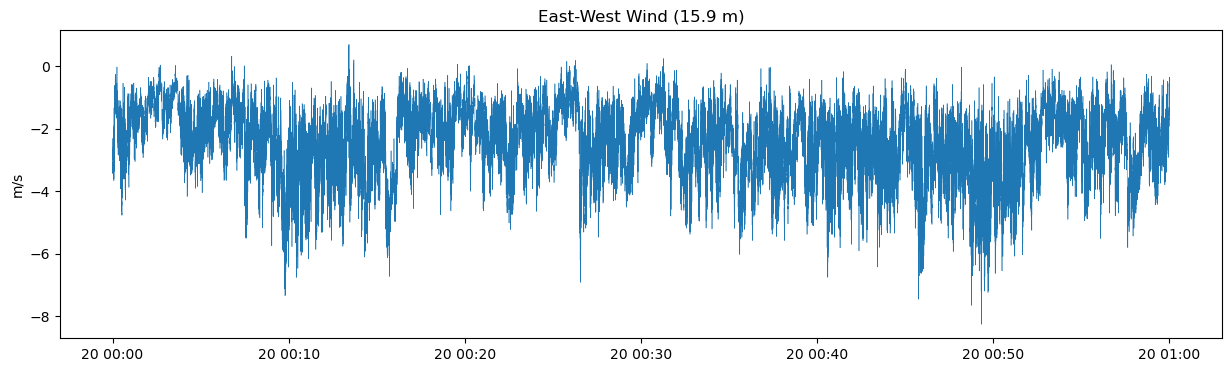

In [5]:
# 4. Plot one hour of wind
import matplotlib.pyplot as plt

n = 50 * 60 * 60     # one hour

plt.figure(figsize=(15,4))

plt.plot(
    ds.time[:n],
    ds.u_15_9m[:n],
    linewidth=.4
)

plt.title("East-West Wind (15.9 m)")
plt.ylabel("m/s")

In [6]:
# 5. Compute statistics from ALL files
import numpy as np

rows = []

for file in files:

    ds = xr.open_dataset(file, decode_times=False)

    rows.append({

        "file": file.name,

        "mean_u": float(ds.u_15_9m.mean()),

        "mean_temp": float(ds.tc_15_9m.mean()),

        "std_w": float(ds.w_15_9m.std()),

        "max_speed": float(
            np.sqrt(ds.u_15_9m**2 + ds.v_15_9m**2).max()
        )

    })

    ds.close()

In [7]:
import pandas as pd

summary = pd.DataFrame(rows)

summary.head()

,file,mean_u,mean_temp,std_w,max_speed
0,csat_20250820_00.nc,-2.166583,23.111482,0.567723,8.270444
1,csat_20250820_04.nc,-1.076291,21.710459,0.342536,4.322221
2,csat_20250820_08.nc,-1.202889,21.378267,0.377995,5.206049
3,csat_20250820_12.nc,-1.524573,23.217213,0.448545,6.440752
4,csat_20250820_16.nc,-1.556064,25.596956,0.479923,6.217237


In [8]:
# 6. Parse dates from filenames
summary["datetime"] = pd.to_datetime(

    summary.file.str.extract(
        r"csat_(\d{8})_(\d{2})"
    ).apply(
        lambda x: x[0] + x[1],
        axis=1
    ),

    format="%Y%m%d%H"

)

summary = summary.sort_values("datetime")

Text(0.5, 1.0, 'Mean Temperature per 4-hour File')

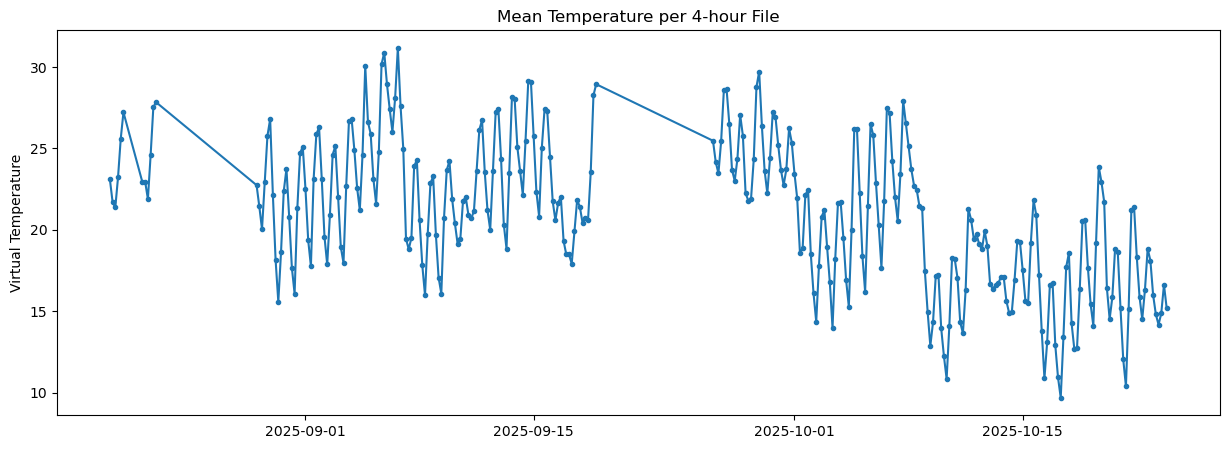

In [9]:
# 7. Temperature over the dataset
plt.figure(figsize=(15,5))

plt.plot(
    summary.datetime,
    summary.mean_temp,
    marker="."
)

plt.ylabel("Virtual Temperature")
plt.title("Mean Temperature per 4-hour File")

Text(0, 0.5, 'Maximum Wind Speed (m/s)')

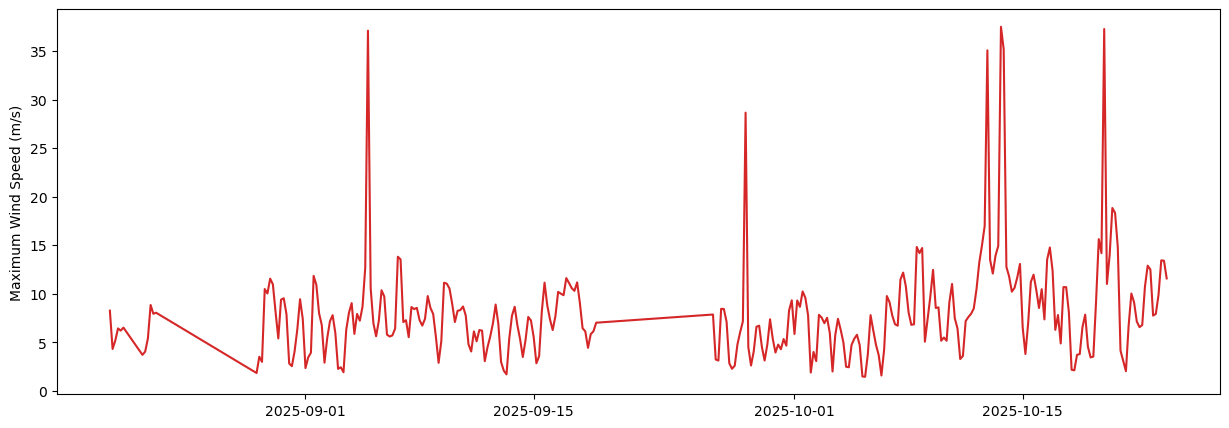

In [10]:
# 8. Wind speed through time
plt.figure(figsize=(15,5))

plt.plot(
    summary.datetime,
    summary.max_speed,
    color="tab:red"
)

plt.ylabel("Maximum Wind Speed (m/s)")

Text(0.5, 1.0, 'Turbulence Indicator')

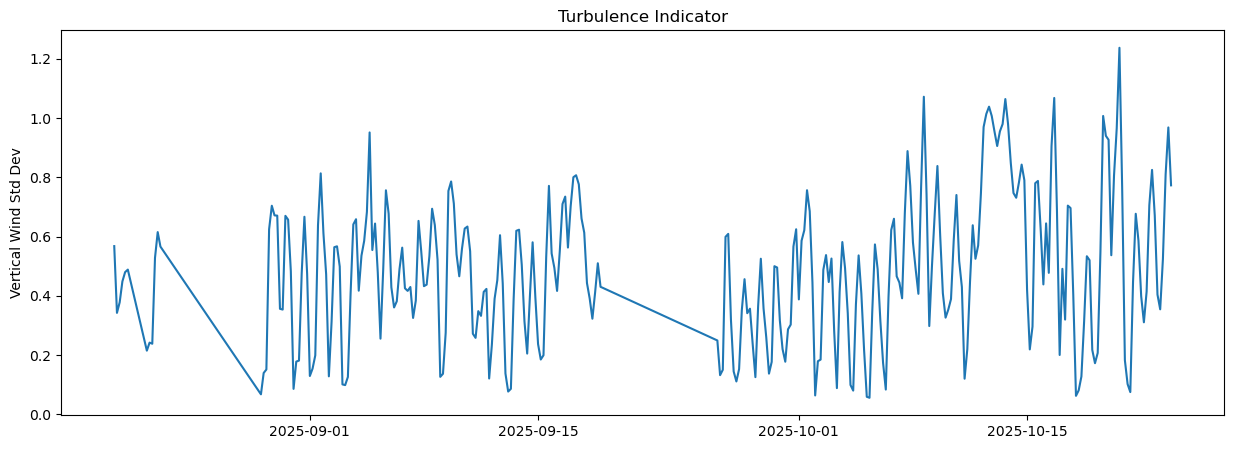

In [11]:
# 9. Turbulence over time

plt.figure(figsize=(15,5))

plt.plot(
    summary.datetime,
    summary.std_w
)

plt.ylabel("Vertical Wind Std Dev")
plt.title("Turbulence Indicator")

Text(0.5, 1.0, 'Maximum Wind Speed')

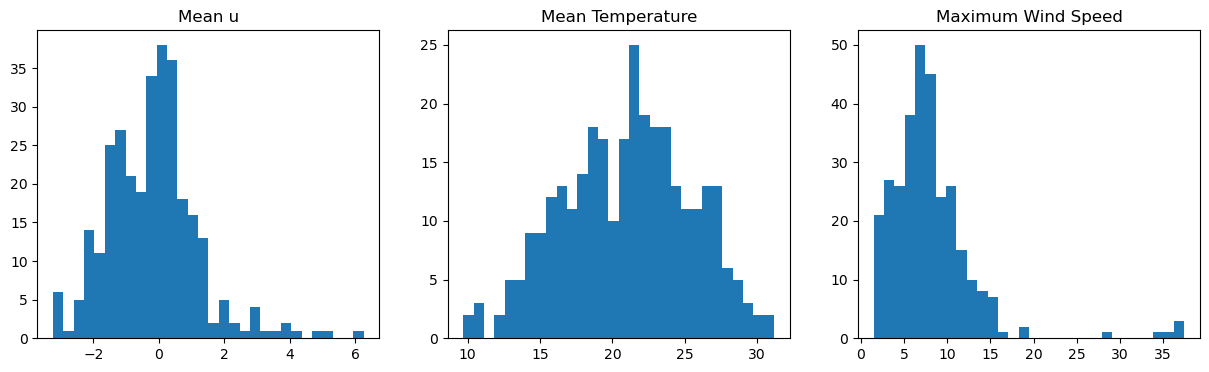

In [12]:
# 10. Histograms
fig, ax = plt.subplots(1,3, figsize=(15,4))

ax[0].hist(summary.mean_u, bins=30)
ax[0].set_title("Mean u")

ax[1].hist(summary.mean_temp, bins=30)
ax[1].set_title("Mean Temperature")

ax[2].hist(summary.max_speed, bins=30)
ax[2].set_title("Maximum Wind Speed")

In [13]:
# 11. Which file had the strongest winds?
summary.sort_values("max_speed", ascending=False).head(10)

,file,mean_u,mean_temp,std_w,max_speed,datetime
244,csat_20251013_16.nc,0.435763,17.109607,1.063975,37.489222,2025-10-13 16:00:00
282,csat_20251020_00.nc,-0.561432,21.712650,0.926480,37.257968,2025-10-20 00:00:00
53,csat_20250904_20.nc,-0.221198,26.625197,0.554508,37.090029,2025-09-04 20:00:00
245,csat_20251013_20.nc,1.283153,17.115830,0.979419,35.185888,2025-10-13 20:00:00
239,csat_20251012_20.nc,-2.270068,19.011249,1.006677,35.063134,2025-10-12 20:00:00
150,csat_20250928_00.nc,-1.280942,22.243675,0.356577,28.649930,2025-09-28 00:00:00
285,csat_20251020_12.nc,5.082698,15.871080,0.965702,18.839012,2025-10-20 12:00:00
286,csat_20251020_16.nc,6.255575,18.827429,1.237037,18.331143,2025-10-20 16:00:00
238,csat_20251012_16.nc,-3.181172,19.926597,1.038275,16.972344,2025-10-12 16:00:00
280,csat_20251019_16.nc,-2.972782,23.868129,1.006946,15.630964,2025-10-19 16:00:00


In [14]:
# 12. Load that file and visualize it
storm = summary.sort_values(
    "max_speed",
    ascending=False
).iloc[0]

storm

file         csat_20251013_16.nc
mean_u                  0.435763
mean_temp              17.109607
std_w                   1.063975
max_speed              37.489222
datetime     2025-10-13 16:00:00
Name: 244, dtype: object

Text(0.5, 1.0, 'csat_20251013_16.nc')

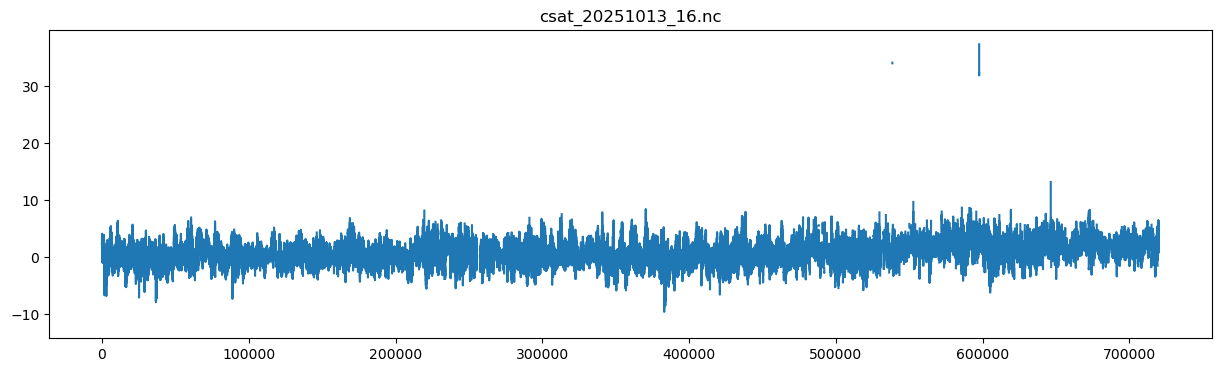

In [15]:
ds = xr.open_dataset(
    broadway / storm.file,
    decode_times=False
)

plt.figure(figsize=(15,4))

plt.plot(ds.u_15_9m)

plt.title(storm.file)

Why I like this notebook

This notebook exercises almost every aspect of your mounted dataset infrastructure:

✅ Discovers mounted files using DATA_DIR
✅ Reads 306 NetCDF files
✅ Extracts metadata from filenames
✅ Computes statistics without exhausting memory
✅ Produces multiple plots summarizing the dataset
✅ Demonstrates a realistic workflow users might perform after mounting a dataset

It's also resilient: if the dataset grows from 306 files to several thousand, the notebook will continue to work because it processes one file at a time rather than trying to concatenate the entire collection into memory.